In [23]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [19]:
# Load data
df = pd.read_parquet("data/2024_XIU.parquet")

# Define option parameters
df['T'] = df["dte"] / 365  
df['r'] = 0.05  
df['S0'] = df["underlying_price"]
df['K'] = df["strike"]

# Compute annualized volatility
df['change_percent'] = df['S0'].pct_change() * 100
df['sigma'] = df['change_percent'].std() * np.sqrt(250)

# Filter for puts with 30-60 DTE
puts = df[df["option_type"] == "put"]
puts_monthly = puts[(puts["dte"] >= 30) & (puts["dte"] <= 60)]

In [21]:
def binomial_tree_american_put(S0, K, r, sigma, T, M=50):
    """
    Computes the price of an American put option using a binomial tree.
    """
    dt = T / M
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # **Fix: Use a 2D NumPy array instead of a list of lists**
    stock_prices = np.zeros((M + 1, M + 1))
    
    for i in range(M + 1):
        for j in range(i + 1):
            stock_prices[i, j] = S0 * (u ** j) * (d ** (i - j))

    # Option value at expiration
    option_values = np.maximum(K - stock_prices[-1, :M + 1], 0)

    # Backward induction
    for i in range(M - 1, -1, -1):
        option_values[:i + 1] = discount * (p * option_values[1:i + 2] + (1 - p) * option_values[:i + 1])
        option_values[:i + 1] = np.maximum(option_values[:i + 1], K - stock_prices[i, :i + 1])

    return option_values[0]


def compute_binomial_prices(df, M=50):
    """
    Batch computation of binomial model prices for American put options.
    """
    return np.array([
        binomial_tree_american_put(S0, K, r, sigma, T, M)
        for S0, K, r, sigma, T in zip(df["S0"], df["K"], df["r"], df["sigma"], df["T"])
    ])

/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_35087/2460055559.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["binomial_price"] = compute_binomial_prices(puts_monthly)


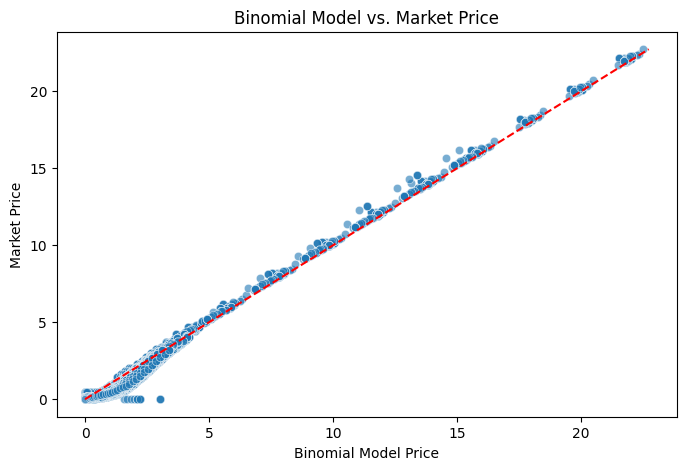

In [22]:
# Compute Binomial Tree Prices
puts_monthly["binomial_price"] = compute_binomial_prices(puts_monthly)

# **Visualization**
plt.figure(figsize=(8, 5))
sns.scatterplot(x=puts_monthly["binomial_price"], y=puts_monthly["last_trade_price"], alpha=0.6)
plt.xlabel("Binomial Model Price")
plt.ylabel("Market Price")
plt.title("Binomial Model vs. Market Price")
plt.plot([puts_monthly["last_trade_price"].min(), puts_monthly["last_trade_price"].max()],
         [puts_monthly["last_trade_price"].min(), puts_monthly["last_trade_price"].max()], "r--")
plt.show()